# Feature engineering and supervised learning

**Assignment 1 - Assessing Bicycle Lane Quality Using Smartphone Sensor Data**  
**Part 2 owner: Amir**

This notebook starts from the validated recordings prepared in `version1.ipynb`. It creates fixed time windows, extracts sensor features, selects features inside the training workflow, and compares four supervised classifiers. The road label belongs to the full recording, so all windows from one recording stay together whenever data is split.

## 1. Setup and reproducibility

The assignment asks for an end-to-end notebook and a clear feature-engineering and supervised-learning stage. The package versions are printed below. The raw recordings are not changed; this notebook reads only the processed handoff in `data/recordings/processed/current/`.

In [1]:
from pathlib import Path
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
SAMPLE_RATE_HZ = 100
WINDOW_SECONDS = 5
OVERLAP_SECONDS = 2.5
WINDOW_SAMPLES = int(WINDOW_SECONDS * SAMPLE_RATE_HZ)
STEP_SAMPLES = int((WINDOW_SECONDS - OVERLAP_SECONDS) * SAMPLE_RATE_HZ)

processed_dir = Path("data/recordings/processed/current")
feature_dir = Path("data/features/supervised/current")
feature_dir.mkdir(parents=True, exist_ok=True)

print(f"Python: {platform.python_version()}")
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"Window: {WINDOW_SECONDS} s ({WINDOW_SAMPLES} samples), {OVERLAP_SECONDS} s overlap")

Python: 3.10.11
numpy: 2.2.6
pandas: 2.3.3
matplotlib: 3.10.9
scikit-learn: 1.6.1
Window: 5 s (500 samples), 2.5 s overlap


## 2. Load the processed recordings

`manifest.csv` gives the stable recording ID, class and paths. The three sensor streams are joined on their nanosecond timestamp rather than row number. This matters because the Part 1 quality check found one extra gyroscope and gravity sample in R020.

In [2]:
manifest = pd.read_csv(processed_dir / "manifest.csv")
required_sensors = {"Accelerometer", "Gyroscope", "Gravity"}

recording_info = manifest[["recording_id", "participant_id", "class"]].drop_duplicates()
assert recording_info["recording_id"].is_unique
assert set(manifest["sensor"]) == required_sensors

print(f"Recordings: {len(recording_info)}")
print(recording_info["class"].value_counts().rename_axis("class").to_frame("recordings"))
recording_info.head()

Recordings: 41
        recordings
class             
bumpy           22
smooth          19


,recording_id,participant_id,class
0,R001,P01,bumpy
3,R002,P01,bumpy
6,R003,P01,bumpy
9,R004,P01,bumpy
12,R005,P01,bumpy


In [3]:
def load_aligned_recording(recording_id):
    sensor_rows = manifest[manifest["recording_id"] == recording_id]
    streams = {}

    for sensor in required_sensors:
        row = sensor_rows[sensor_rows["sensor"] == sensor].iloc[0]
        stream = pd.read_csv(processed_dir / row["relative_path"], float_precision="round_trip")
        streams[sensor] = stream[["time", "seconds_elapsed", "x", "y", "z"]].copy()

    merged = streams["Accelerometer"].rename(
        columns={axis: f"acc_{axis}" for axis in ["x", "y", "z"]}
    )
    merged = merged.rename(columns={"seconds_elapsed": "seconds_elapsed_acc"})

    for sensor, prefix in [("Gyroscope", "gyro"), ("Gravity", "gravity")]:
        stream = streams[sensor][["time", "x", "y", "z"]].rename(
            columns={axis: f"{prefix}_{axis}" for axis in ["x", "y", "z"]}
        )
        merged = merged.merge(stream, on="time", how="inner", validate="one_to_one")

    merged = merged.rename(columns={"seconds_elapsed_acc": "seconds_elapsed"})
    for prefix in ["acc", "gyro", "gravity"]:
        axes = [f"{prefix}_{axis}" for axis in ["x", "y", "z"]]
        merged[f"{prefix}_magnitude"] = np.sqrt((merged[axes] ** 2).sum(axis=1))

    return merged.sort_values("time").reset_index(drop=True)

example_id = recording_info.iloc[0]["recording_id"]
example = load_aligned_recording(example_id)
print(f"{example_id}: {len(example)} aligned samples")
example.head()

R001: 4170 aligned samples


,time,seconds_elapsed,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,gravity_x,gravity_y,gravity_z,acc_magnitude,gyro_magnitude,gravity_magnitude
0,1788862107461369600,0.045370,-0.227989,-0.347207,-0.713455,0.022289,-0.405765,0.189336,-0.413807,1.767118,9.637243,0.825560,0.448320,9.80665
1,1788862107471376400,0.055376,-0.221322,-0.322843,-0.676802,-0.026957,-0.500684,0.377980,-0.364958,1.768043,9.639047,0.781839,0.627917,9.80665
2,1788862107481384400,0.065385,0.057028,-0.293544,-0.487768,-0.082470,-0.596804,0.555704,-0.303781,1.764332,9.641848,0.572135,0.819623,9.80665
3,1788862107491391500,0.075392,0.635013,-0.196537,-0.417952,-0.118726,-0.649369,0.658645,-0.231890,1.756060,9.645355,0.785208,0.932517,9.80665
4,1788862107501398500,0.085398,0.567141,-0.185778,-0.421297,-0.134990,-0.483420,0.666920,-0.164017,1.745301,9.648700,0.730516,0.834686,9.80665


## 3. Windowing strategy

A five-second window contains about 500 measurements at the intended 100 Hz. Adjacent windows overlap by 2.5 seconds, so short changes in vibration are less likely to sit only on a boundary. Windows shorter than five seconds are left out because the feature values would not be comparable to full windows. This is a fixed rule, applied before model evaluation.

The label is copied from the recording to its windows. This is an approximation: a road may contain local variation, and the data does not include a label for each individual bump.

In [4]:
def summarise_signal(values, feature_prefix):
    values = np.asarray(values, dtype=float)
    mean_value = values.mean()
    return {
        f"{feature_prefix}_mean": mean_value,
        f"{feature_prefix}_std": values.std(ddof=0),
        f"{feature_prefix}_min": values.min(),
        f"{feature_prefix}_max": values.max(),
        f"{feature_prefix}_range": values.max() - values.min(),
        f"{feature_prefix}_median": np.median(values),
        f"{feature_prefix}_iqr": np.percentile(values, 75) - np.percentile(values, 25),
        f"{feature_prefix}_rms": np.sqrt(np.mean(values ** 2)),
        f"{feature_prefix}_mean_abs": np.mean(np.abs(values)),
        f"{feature_prefix}_energy": np.mean(values ** 2),
        f"{feature_prefix}_zero_crossings": np.count_nonzero(np.diff(np.signbit(values - mean_value))),
    }


def make_window_features(recording, metadata):
    signal_columns = [column for column in recording.columns if column not in {"time", "seconds_elapsed"}]
    rows = []

    for start in range(0, len(recording) - WINDOW_SAMPLES + 1, STEP_SAMPLES):
        window = recording.iloc[start:start + WINDOW_SAMPLES]
        row = {
            "recording_id": metadata.recording_id,
            "participant_id": metadata.participant_id,
            "class": metadata[2],
            "window_start_seconds": window["seconds_elapsed"].iloc[0],
            "window_end_seconds": window["seconds_elapsed"].iloc[-1],
        }
        for signal in signal_columns:
            row.update(summarise_signal(window[signal].to_numpy(), signal))
        rows.append(row)

    return rows

window_rows = []
alignment_rows = []
for metadata in recording_info.itertuples(index=False):
    recording = load_aligned_recording(metadata.recording_id)
    window_rows.extend(make_window_features(recording, metadata))
    alignment_rows.append({
        "recording_id": metadata.recording_id,
        "aligned_samples": len(recording),
        "windows": len(make_window_features(recording, metadata)),
    })

feature_table = pd.DataFrame(window_rows)
alignment_table = pd.DataFrame(alignment_rows)
feature_table.to_csv(feature_dir / "window_features.csv", index=False)
alignment_table.to_csv(feature_dir / "windowing_summary.csv", index=False)

print(f"Created {len(feature_table)} windows from {feature_table['recording_id'].nunique()} recordings.")
print(feature_table["class"].value_counts().rename_axis("class").to_frame("windows"))
alignment_table.describe()

Created 709 windows from 41 recordings.
        windows
class          
bumpy       382
smooth      327


,aligned_samples,windows
count,41.000000,41.000000
mean,4691.853659,17.292683
std,536.518572,2.124193
min,3229.000000,11.000000
25%,4268.000000,16.000000
50%,4802.000000,18.000000
75%,5065.000000,19.000000
max,5610.000000,21.000000


## 4. Inspect the feature table

The plot shows two intuitive acceleration features before fitting a model. The full feature table contains statistics from every accelerometer, gyroscope and gravity axis plus their magnitudes. Recording ID, participant ID and window time are retained only for tracing and splitting; they are not model features.

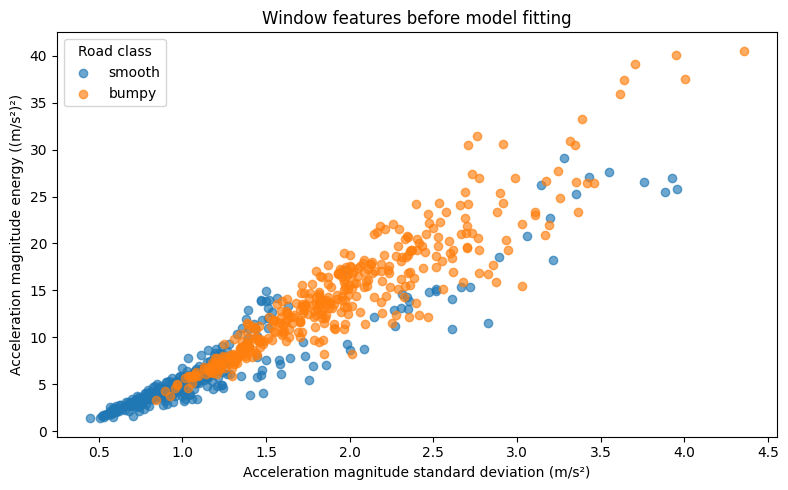

Candidate numerical features: 132


In [5]:
plt.figure(figsize=(8, 5))
for road_class, color in [("smooth", "tab:blue"), ("bumpy", "tab:orange")]:
    subset = feature_table[feature_table["class"] == road_class]
    plt.scatter(
        subset["acc_magnitude_std"],
        subset["acc_magnitude_energy"],
        label=road_class,
        alpha=0.65,
        color=color,
    )
plt.xlabel("Acceleration magnitude standard deviation (m/s²)")
plt.ylabel("Acceleration magnitude energy ((m/s²)²)")
plt.title("Window features before model fitting")
plt.legend(title="Road class")
plt.tight_layout()
plt.show()

metadata_columns = ["recording_id", "participant_id", "class", "window_start_seconds", "window_end_seconds"]
feature_columns = [column for column in feature_table.columns if column not in metadata_columns]
print(f"Candidate numerical features: {len(feature_columns)}")

## 5. Grouped training and test split

The test set is made with `StratifiedGroupKFold`, using recording ID as the group. It keeps all windows from a ride on one side of the split and tries to preserve the smooth/bumpy balance. This gives a more honest estimate than randomly splitting individual windows, which would mix highly similar parts of the same ride across the two sets.

Scaling and feature selection are placed inside each model pipeline. They are therefore fitted using only the relevant training fold, which avoids information leaking from the test set into the preprocessing steps.

In [6]:
X = feature_table[feature_columns]
y = feature_table["class"]
groups = feature_table["recording_id"]

outer_splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_index, test_index = next(outer_splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_index], X.iloc[test_index]
y_train, y_test = y.iloc[train_index], y.iloc[test_index]
groups_train, groups_test = groups.iloc[train_index], groups.iloc[test_index]

assert set(groups_train).isdisjoint(set(groups_test))
print(f"Training: {len(X_train)} windows from {groups_train.nunique()} recordings")
print(f"Test: {len(X_test)} windows from {groups_test.nunique()} recordings")
print("\nTraining class counts:")
print(y_train.value_counts())
print("\nTest class counts:")
print(y_test.value_counts())

Training: 573 windows from 33 recordings
Test: 136 windows from 8 recordings

Training class counts:
class
bumpy     293
smooth    280
Name: count, dtype: int64

Test class counts:
class
bumpy     89
smooth    47
Name: count, dtype: int64


## 6. Feature selection and four supervised models

The feature-selection methods follow the feature-engineering lecture. First, variance thresholding removes a feature only when it has no variation in the training data. Next, when two remaining features have an absolute Pearson correlation above 0.95, one is removed because it contains almost the same information as the other. The selection is fitted on training rides only.

The four models are logistic regression, k-nearest neighbours, a decision tree and a random forest. They represent a linear baseline, a distance-based method, one interpretable tree, and a tree ensemble.

Features before selection: 132
After variance thresholding: 132
After correlation selection: 91


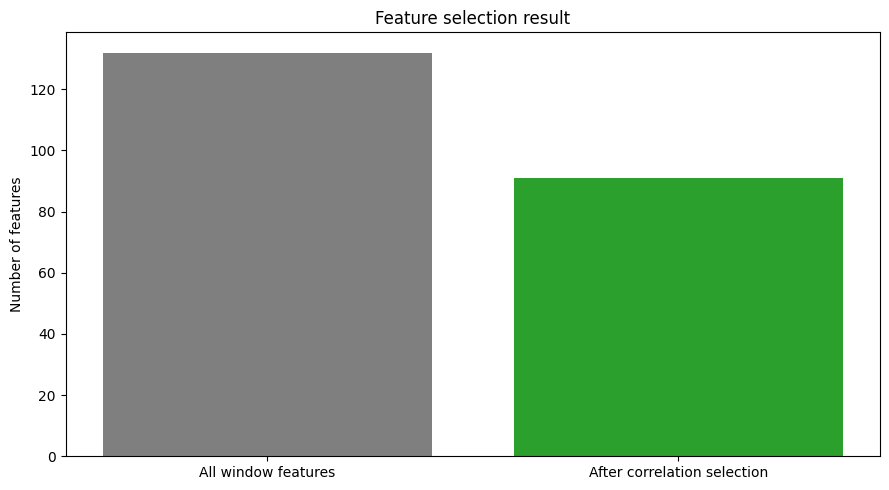

,feature,variance_on_training_data,maximum_absolute_correlation,selected
0,acc_x_mean,2.304336e-02,0.000000,True
1,acc_x_std,7.333421e-01,0.021357,True
2,acc_x_min,1.077882e+01,0.824871,True
3,acc_x_max,1.703932e+01,0.861752,True
5,acc_x_median,3.362025e-02,0.827532,True
...,...,...,...,...
124,gravity_magnitude_max,1.826886e-13,0.761229,True
125,gravity_magnitude_range,5.612124e-13,0.908904,True
126,gravity_magnitude_median,1.202721e-14,0.875456,True
127,gravity_magnitude_iqr,1.248666e-13,0.945313,True


In [7]:
variance_selector = VarianceThreshold(threshold=0.0).fit(X_train)
features_with_variance = X_train.columns[variance_selector.get_support()].tolist()

training_correlation = X_train[features_with_variance].corr().abs()
upper_triangle = training_correlation.where(
    np.triu(np.ones(training_correlation.shape), k=1).astype(bool)
)
redundant_features = [
    column for column in upper_triangle.columns if (upper_triangle[column] > 0.95).any()
]
selected_feature_columns = [
    column for column in features_with_variance if column not in redundant_features
]

maximum_correlation = upper_triangle.max(axis=0).fillna(0.0)
feature_selection_table = pd.DataFrame({
    "feature": feature_columns,
    "variance_on_training_data": X_train.var(ddof=0).reindex(feature_columns).to_numpy(),
    "maximum_absolute_correlation": maximum_correlation.reindex(feature_columns).fillna(0.0).to_numpy(),
})
feature_selection_table["selected"] = feature_selection_table["feature"].isin(selected_feature_columns)
selected_features = feature_selection_table[feature_selection_table["selected"]].copy()
feature_selection_table.to_csv(feature_dir / "feature_selection_scores.csv", index=False)
selected_features.to_csv(feature_dir / "selected_features.csv", index=False)

print(f"Features before selection: {len(feature_columns)}")
print(f"After variance thresholding: {len(features_with_variance)}")
print(f"After correlation selection: {len(selected_feature_columns)}")
plt.figure(figsize=(9, 5))
feature_counts = pd.DataFrame({
    "stage": ["All window features", "After correlation selection"],
    "number_of_features": [len(feature_columns), len(selected_feature_columns)],
})
plt.bar(feature_counts["stage"], feature_counts["number_of_features"], color=["tab:gray", "tab:green"])
plt.ylabel("Number of features")
plt.title("Feature selection result")
plt.tight_layout()
plt.show()

selected_features

In [8]:
models = {
    "Logistic regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "K-nearest neighbours": KNeighborsClassifier(n_neighbors=9),
    "Decision tree": DecisionTreeClassifier(max_depth=8, min_samples_leaf=5, random_state=RANDOM_STATE),
    "Random forest": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

model_pipelines = {
    name: Pipeline([
        ("scale", StandardScaler()),
        ("model", estimator),
    ])
    for name, estimator in models.items()
}

X_train_selected = X_train[selected_feature_columns]
X_test_selected = X_test[selected_feature_columns]
inner_splitter = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "f1_macro": "f1_macro"}
comparison_rows = []

for name, pipeline in model_pipelines.items():
    scores = cross_validate(
        pipeline,
        X_train_selected,
        y_train,
        groups=groups_train,
        cv=inner_splitter,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )
    comparison_rows.append({
        "model": name,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_accuracy_std": scores["test_accuracy"].std(ddof=1),
        "cv_f1_macro_mean": scores["test_f1_macro"].mean(),
        "cv_f1_macro_std": scores["test_f1_macro"].std(ddof=1),
    })

comparison = pd.DataFrame(comparison_rows).sort_values("cv_f1_macro_mean", ascending=False)
comparison.to_csv(feature_dir / "supervised_model_comparison.csv", index=False)
comparison.round(3)

,model,cv_accuracy_mean,cv_accuracy_std,cv_f1_macro_mean,cv_f1_macro_std
3,Random forest,0.942,0.043,0.941,0.043
0,Logistic regression,0.940,0.036,0.939,0.036
1,K-nearest neighbours,0.900,0.046,0.898,0.047
2,Decision tree,0.891,0.045,0.888,0.046


## 7. Final held-out test evaluation

The model with the highest grouped cross-validation macro F1 score is fitted once on all training rides and then evaluated on the untouched test rides. Macro F1 gives equal weight to smooth and bumpy windows, while accuracy gives an overall proportion of correct predictions. The final numbers printed below are the results to report for this split; they should not be used to tune the model further.

Selected model: Random forest
Held-out accuracy: 0.956
Held-out macro F1: 0.952

Classification report:
              precision    recall  f1-score   support

       bumpy      0.988     0.944     0.966        89
      smooth      0.902     0.979     0.939        47

    accuracy                          0.956       136
   macro avg      0.945     0.961     0.952       136
weighted avg      0.958     0.956     0.956       136



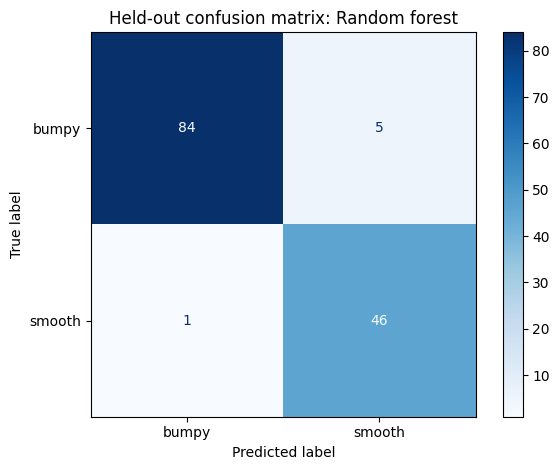

In [9]:
best_model_name = comparison.iloc[0]["model"]
best_pipeline = clone(model_pipelines[best_model_name])
best_pipeline.fit(X_train_selected, y_train)
y_pred = best_pipeline.predict(X_test_selected)

test_accuracy = accuracy_score(y_test, y_pred)
test_f1_macro = f1_score(y_test, y_pred, average="macro")
test_results = pd.DataFrame([{
    "selected_model": best_model_name,
    "test_accuracy": test_accuracy,
    "test_f1_macro": test_f1_macro,
    "train_recordings": groups_train.nunique(),
    "test_recordings": groups_test.nunique(),
    "train_windows": len(X_train),
    "test_windows": len(X_test),
}])
test_results.to_csv(feature_dir / "held_out_test_results.csv", index=False)

print(f"Selected model: {best_model_name}")
print(f"Held-out accuracy: {test_accuracy:.3f}")
print(f"Held-out macro F1: {test_f1_macro:.3f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title(f"Held-out confusion matrix: {best_model_name}")
plt.tight_layout()
plt.show()

## 8. Handoff to the next stage

This notebook writes the window-level feature table, the windowing summary, variance and correlation feature-selection results, selected features, grouped cross-validation comparison and one held-out test result to `data/features/supervised/current/`. The exports retain recording ID and window time for traceability, but those fields were excluded from model fitting.

The result is limited by the small number of recordings and by the collection structure described in Part 1. In particular, several rides share a participant, route or recording session, so even a grouped ride-level split can be optimistic for a new rider or route. The external deployment recording remains untouched here and should be used only after the group chooses its final model.

In [10]:
print("Saved Part 2 outputs:")
for path in sorted(feature_dir.glob("*.csv")):
    print(f"- {path}")

print("\nImportant handoff notes:")
print("- recording IDs are present for tracing and grouped splitting, not as model features.")
print("- scaling and feature selection were fitted inside the training workflow.")
print("- external deployment data was not used for training, validation or testing.")

Saved Part 2 outputs:
- data/features/supervised/current/feature_selection_scores.csv
- data/features/supervised/current/held_out_test_results.csv
- data/features/supervised/current/selected_features.csv
- data/features/supervised/current/supervised_model_comparison.csv
- data/features/supervised/current/window_features.csv
- data/features/supervised/current/windowing_summary.csv

Important handoff notes:
- recording IDs are present for tracing and grouped splitting, not as model features.
- scaling and feature selection were fitted inside the training workflow.
- external deployment data was not used for training, validation or testing.
